<a href="https://colab.research.google.com/github/hedil1/deep_learning_project/blob/main/COLAB_01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Projet Deep Learning — Détection de l'Endométriose
## Notebook 01 — Exploration & Analyse du Dataset



##  Étape 1 — Installation & Imports

In [ ]:
from google.colab import files

print(' Upload dataset.zip ...')
uploaded = files.upload()  # upload ton zip

# Décompresser
!unzip -q dataset.zip -d dataset/

# Vérifier
import os
print(os.listdir('dataset/'))

 Upload dataset.zip ...


KeyboardInterrupt: 

In [ ]:
# Installation
!pip install kaggle -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
np.random.seed(42)

print('✅ Bibliothèques chargées')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

✅ Bibliothèques chargées
NumPy  : 2.0.2
Pandas : 2.2.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##  Étape 2 — Téléchargement du Dataset



In [ ]:
# ===========================
#  CHEMINS COLAB CORRECTS
# ===========================
BASE_INPUT   = 'dataset/dataset'
ENDO_DIR     = os.path.join(BASE_INPUT, 'endometriosis')
NON_ENDO_DIR = os.path.join(BASE_INPUT, 'no_endometriosis')
WORK_DIR     = '/content'
IMG_EXT      = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')

print('🔍 Vérification des chemins :')
print(f'   ENDO_DIR     → existe : {os.path.exists(ENDO_DIR)}')
print(f'   NON_ENDO_DIR → existe : {os.path.exists(NON_ENDO_DIR)}')

# Si les chemins ne marchent pas, afficher la vraie structure
if not os.path.exists(ENDO_DIR):
    print('\n Chemin introuvable — structure réelle :')
    for root, dirs, files_list in os.walk('dataset'):
        level = root.replace('dataset', '').count(os.sep)
        nb = len([f for f in files_list if f.lower().endswith(('.jpg','.jpeg','.png'))])
        if nb > 0:
            print(f'  {"  "*level} {root}  → {nb} images')
else:
    print('\n✅ Tous les chemins sont valides !')

🔍 Vérification des chemins :
   ENDO_DIR     → existe : True
   NON_ENDO_DIR → existe : True

✅ Tous les chemins sont valides !


## Étape 3 — Distribution des Classes

In [ ]:
def count_images(directory):
    if not os.path.exists(directory):
        return 0
    return len([f for f in os.listdir(directory)
                if os.path.splitext(f)[1].lower() in IMG_EXT])

n_endo     = count_images(ENDO_DIR)
n_non_endo = count_images(NON_ENDO_DIR)
n_total    = n_endo + n_non_endo

print('📊 Distribution des Classes')
print('=' * 45)
print(f' Endométriose     : {n_endo:>5} images  ({n_endo/n_total*100:.1f}%)')
print(f' No-Endométriose  : {n_non_endo:>5} images  ({n_non_endo/n_total*100:.1f}%)')
print(f' Total            : {n_total:>5} images')
print('=' * 45)

ratio = max(n_endo, n_non_endo) / (min(n_endo, n_non_endo) + 1e-6)
if ratio > 1.3:
    print(f'  Déséquilibre (ratio={ratio:.2f}) → utiliser class_weight')
else:
    print(' Classes relativement équilibrées')

📊 Distribution des Classes
 Endométriose     :   533 images  (52.2%)
 No-Endométriose  :   489 images  (47.8%)
 Total            :  1022 images
 Classes relativement équilibrées


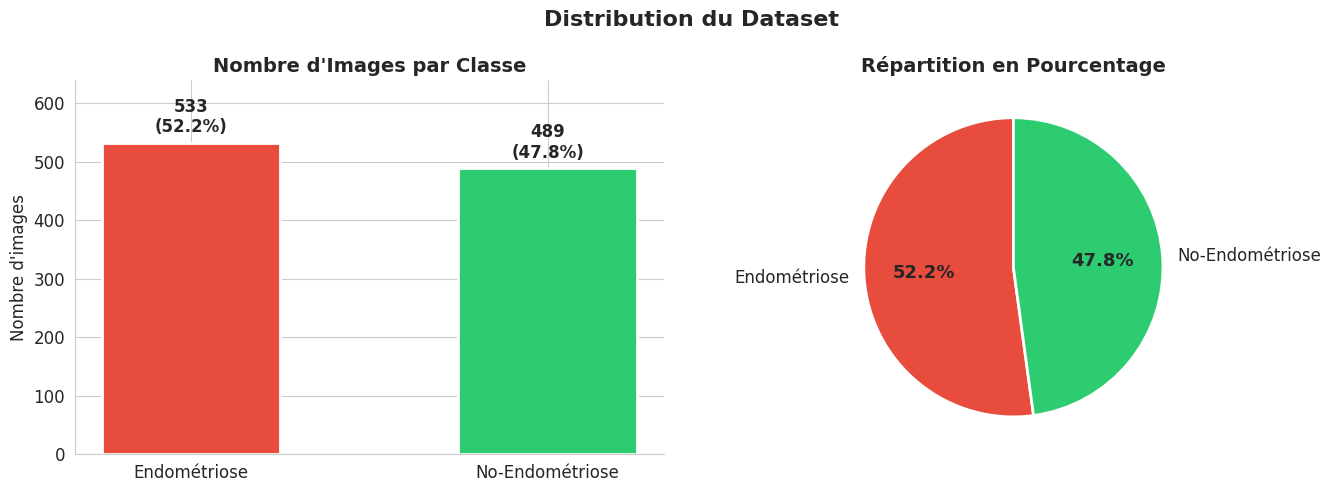

Sauvegardé : distribution_classes.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = ['Endométriose', 'No-Endométriose']
counts  = [n_endo, n_non_endo]
colors  = ['#E74C3C', '#2ECC71']

bars = axes[0].bar(classes, counts, color=colors, edgecolor='white', linewidth=2, width=0.5)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+max(counts)*0.02,
                 f'{count}\n({count/n_total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Nombre d\'Images par Classe', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre d\'images')
axes[0].set_ylim(0, max(counts)*1.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

wedges, texts, autotexts = axes[1].pie(
    counts, labels=classes, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold')
axes[1].set_title('Répartition en Pourcentage', fontsize=14, fontweight='bold')

plt.suptitle('Distribution du Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : distribution_classes.png')

##  Étape 4 — Visualisation des Images

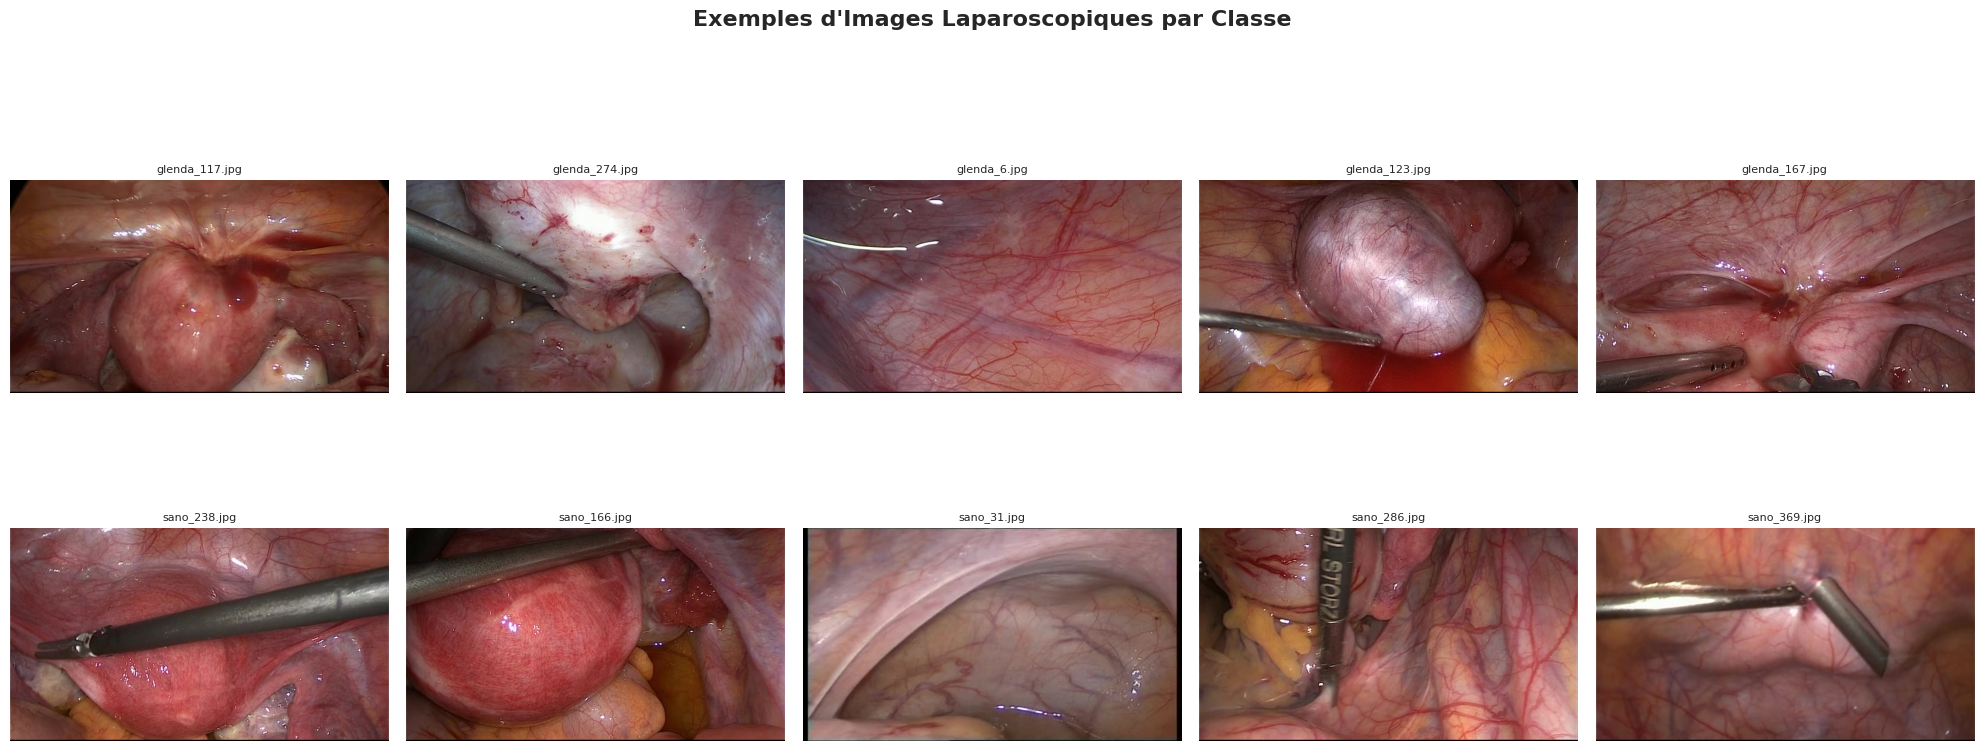

 Sauvegardé : sample_images.png


In [ ]:
def load_sample_images(directory, n=5):
    files = [f for f in os.listdir(directory)
             if os.path.splitext(f)[1].lower() in IMG_EXT]
    np.random.seed(42)
    selected = np.random.choice(files, min(n, len(files)), replace=False)
    return [(Image.open(os.path.join(directory, f)).convert('RGB'), f) for f in selected]

endo_samples     = load_sample_images(ENDO_DIR, 5)
non_endo_samples = load_sample_images(NON_ENDO_DIR, 5)

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
for i, (img, fname) in enumerate(endo_samples):
    axes[0,i].imshow(img); axes[0,i].set_title(fname[:18], fontsize=8); axes[0,i].axis('off')
    for sp in axes[0,i].spines.values():
        sp.set_visible(True); sp.set_color('#E74C3C'); sp.set_linewidth(3)

for i, (img, fname) in enumerate(non_endo_samples):
    axes[1,i].imshow(img); axes[1,i].set_title(fname[:18], fontsize=8); axes[1,i].axis('off')
    for sp in axes[1,i].spines.values():
        sp.set_visible(True); sp.set_color('#2ECC71'); sp.set_linewidth(3)

axes[0,0].set_ylabel('🔴 Endométriose',   fontsize=13, fontweight='bold', color='#E74C3C', labelpad=10)
axes[1,0].set_ylabel('🟢 No-Endométriose',fontsize=13, fontweight='bold', color='#2ECC71', labelpad=10)

plt.suptitle('Exemples d\'Images Laparoscopiques par Classe', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : sample_images.png')

## Étape 5 — Analyse des Propriétés

In [ ]:
def analyze_images(directory, class_name, max_images=150):
    files = [f for f in os.listdir(directory)
             if os.path.splitext(f)[1].lower() in IMG_EXT][:max_images]
    widths, heights, sizes = [], [], []
    for fname in files:
        try:
            img = Image.open(os.path.join(directory, fname))
            w, h = img.size
            widths.append(w); heights.append(h)
            sizes.append(os.path.getsize(os.path.join(directory, fname)) / 1024)
        except: pass
    return pd.DataFrame({'classe': class_name, 'largeur': widths,
                         'hauteur': heights, 'taille_kb': sizes})

df_endo     = analyze_images(ENDO_DIR,     'Endométriose')
df_non_endo = analyze_images(NON_ENDO_DIR, 'No-Endométriose')
df_all      = pd.concat([df_endo, df_non_endo], ignore_index=True)

print(' Statistiques :')
print(df_all.groupby('classe')[['largeur', 'hauteur', 'taille_kb']].describe().round(1))

 Statistiques :
                largeur                                                  \
                  count   mean   std    min    25%    50%    75%    max   
classe                                                                    
Endométriose      150.0  638.9  13.1  480.0  640.0  640.0  640.0  640.0   
No-Endométriose   150.0  640.0   0.0  640.0  640.0  640.0  640.0  640.0   

                hauteur         ...               taille_kb                    \
                  count   mean  ...    75%    max     count  mean   std   min   
classe                          ...                                             
Endométriose      150.0  360.0  ...  360.0  360.0     150.0  70.0  12.6  32.2   
No-Endométriose   150.0  360.0  ...  360.0  360.0     150.0  62.4  14.1  20.4   

                                          
                  25%   50%   75%    max  
classe                                    
Endométriose     61.6  69.6  78.2  100.2  
No-Endométriose  53.9  63.2  7

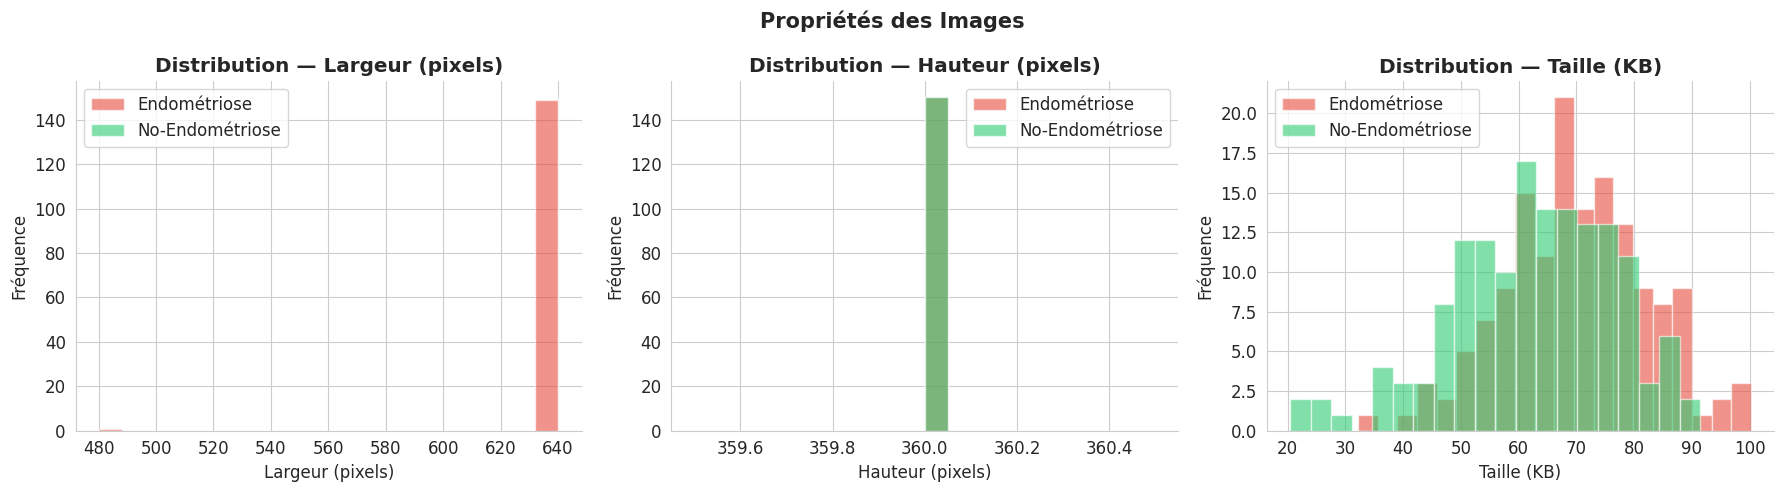

✅ Sauvegardé : image_properties.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_map = {'Endométriose': '#E74C3C', 'No-Endométriose': '#2ECC71'}

for col, ax, label in zip(
    ['largeur','hauteur','taille_kb'], axes,
    ['Largeur (pixels)','Hauteur (pixels)','Taille (KB)']
):
    for classe, grp in df_all.groupby('classe'):
        ax.hist(grp[col], alpha=0.6, bins=20, label=classe,
                color=colors_map[classe], edgecolor='white')
    ax.set_title(f'Distribution — {label}', fontweight='bold')
    ax.set_xlabel(label); ax.set_ylabel('Fréquence'); ax.legend()
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Propriétés des Images', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/image_properties.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : image_properties.png')

## 🌈 Étape 6 — Histogrammes RGB

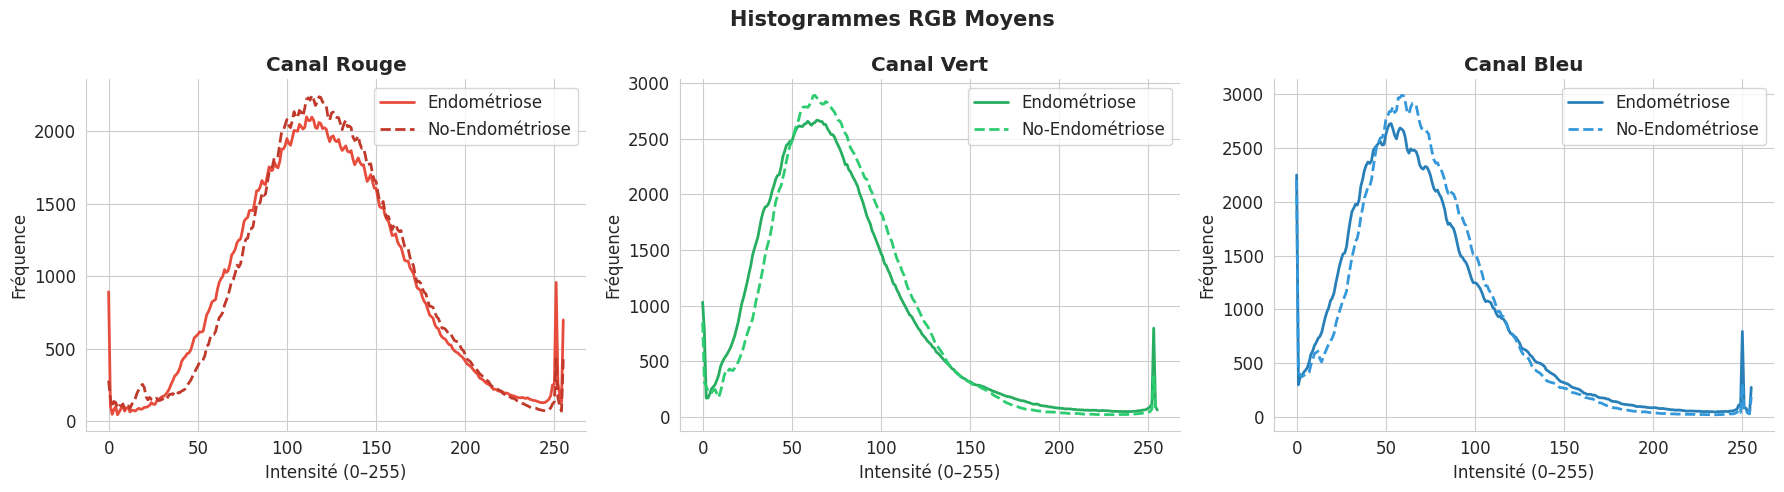

✅ Sauvegardé : rgb_histograms.png


In [ ]:
def compute_avg_histogram(directory, n=50):
    files = [f for f in os.listdir(directory)
             if os.path.splitext(f)[1].lower() in IMG_EXT][:n]
    hr, hg, hb = np.zeros(256), np.zeros(256), np.zeros(256)
    count = 0
    for fname in files:
        try:
            img = np.array(Image.open(os.path.join(directory, fname)).convert('RGB'))
            hr += np.histogram(img[:,:,0], bins=256, range=(0,256))[0]
            hg += np.histogram(img[:,:,1], bins=256, range=(0,256))[0]
            hb += np.histogram(img[:,:,2], bins=256, range=(0,256))[0]
            count += 1
        except: pass
    count = max(count, 1)
    return hr/count, hg/count, hb/count

er, eg, eb = compute_avg_histogram(ENDO_DIR)
nr, ng, nb = compute_avg_histogram(NON_ENDO_DIR)
x = np.arange(256)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, e_h, n_h, c1, c2) in zip(axes, [
    ('Canal Rouge', er, nr, '#E74C3C', '#C0392B'),
    ('Canal Vert',  eg, ng, '#27AE60', '#2ECC71'),
    ('Canal Bleu',  eb, nb, '#2980B9', '#3498DB'),
]):
    ax.plot(x, e_h, color=c1, label='Endométriose',    linewidth=2)
    ax.plot(x, n_h, color=c2, label='No-Endométriose', linewidth=2, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Intensité (0–255)'); ax.set_ylabel('Fréquence'); ax.legend()
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Histogrammes RGB Moyens', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/rgb_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : rgb_histograms.png')

## 📝 Étape 7 — Résumé & Sauvegarde

In [ ]:
import json

config = {
    'BASE_INPUT':   BASE_INPUT,
    'ENDO_DIR':     ENDO_DIR,
    'NON_ENDO_DIR': NON_ENDO_DIR,
    'WORK_DIR':     WORK_DIR,
    'n_endo':       int(n_endo),
    'n_non_endo':   int(n_non_endo),
    'n_total':      int(n_total)
}
with open(f'{WORK_DIR}/config_paths.json', 'w') as f:
    json.dump(config, f, indent=2)
df_all.to_csv(f'{WORK_DIR}/dataset_statistics.csv', index=False)

print('=' * 55)
print('     📋 RÉSUMÉ EXPLORATION')
print('=' * 55)
print(f'  Total images     : {n_total}')
print(f'  Endométriose     : {n_endo}  ({n_endo/n_total*100:.1f}%)')
print(f'  No-Endométriose  : {n_non_endo}  ({n_non_endo/n_total*100:.1f}%)')
print(f'  Largeur moyenne  : {df_all["largeur"].mean():.0f} px')
print(f'  Hauteur moyenne  : {df_all["hauteur"].mean():.0f} px')
print()
print('  ✅ config_paths.json')
print('  ✅ dataset_statistics.csv')
print('  ✅ distribution_classes.png')
print('  ✅ sample_images.png')
print('  ✅ image_properties.png')
print('  ✅ rgb_histograms.png')
print()
print('  🔜 Prochaine étape : Notebook 02 — Prétraitement')
print('=' * 55)

     📋 RÉSUMÉ EXPLORATION
  Total images     : 1022
  Endométriose     : 533  (52.2%)
  No-Endométriose  : 489  (47.8%)
  Largeur moyenne  : 639 px
  Hauteur moyenne  : 360 px

  ✅ config_paths.json
  ✅ dataset_statistics.csv
  ✅ distribution_classes.png
  ✅ sample_images.png
  ✅ image_properties.png
  ✅ rgb_histograms.png

  🔜 Prochaine étape : Notebook 02 — Prétraitement


🔬 Projet Deep Learning — Détection de l'Endométriose
Notebook 02 — Prétraitement & Augmentation
Auteur : [Ton Nom]
Encadrant : M. Abdallah Khemais
Plateforme : Google Colab

🎯 Objectif
Redimensionner et normaliser les images (224×224, [0,1])
Diviser : 70% train / 15% val / 15% test
Appliquer l'augmentation de données sur le train
Créer les générateurs Keras prêts pour l'entraînement
⚠️ Prérequis : Le Notebook 01 doit avoir été exécuté dans la même session Colab

# 🔬 Projet Deep Learning — Détection de l'Endométriose
## Notebook 02 — Prétraitement & Augmentation
---
###  Objectif
- Redimensionner et normaliser les images (224×224, [0,1])

- Diviser : 70% train / 15% val / 15% test
- Appliquer l'augmentation de données sur le train Créer les générateurs Keras prêts pour l'entraînement


## 📦 Étape 1 — Imports & Configuration

In [ ]:
import os, shutil, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(' Tous les imports OK')

 Tous les imports OK


In [ ]:
import os, shutil, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style('whitegrid')

print('✅ Bibliothèques chargées')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU dispo  : {len(tf.config.list_physical_devices("GPU")) > 0}')

In [ ]:
# ===========================
#  CONFIGURATION COLAB
# ===========================
BASE_INPUT   = 'dataset/dataset'
ENDO_DIR     = os.path.join(BASE_INPUT, 'endometriosis')
NON_ENDO_DIR = os.path.join(BASE_INPUT, 'no_endometriosis')
WORK_DIR     = '/content'
OUTPUT_DIR   = '/content/data_split'

IMG_SIZE     = (224, 224)
INPUT_SHAPE  = (224, 224, 3)
BATCH_SIZE   = 32
IMG_EXT      = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')
CLASSES      = ['endometriosis', 'no_endometriosis']

TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15

print('⚙️  Configuration :')
print(f'   ENDO_DIR     → existe : {os.path.exists(ENDO_DIR)}')
print(f'   NON_ENDO_DIR → existe : {os.path.exists(NON_ENDO_DIR)}')
print(f'   IMG_SIZE     : {IMG_SIZE}')
print(f'   BATCH_SIZE   : {BATCH_SIZE}')

⚙️  Configuration :
   ENDO_DIR     → existe : True
   NON_ENDO_DIR → existe : True
   IMG_SIZE     : (224, 224)
   BATCH_SIZE   : 32


## 📂 Étape 2 — Split Train / Val / Test

In [ ]:


def collect_paths(directory, label):
    return [
        {'path': os.path.join(directory, f), 'label': label, 'filename': f}
        for f in os.listdir(directory)
        if os.path.splitext(f)[1].lower() in IMG_EXT
    ]

def create_split_folders(output_dir, classes):
    for split in ['train', 'val', 'test']:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)
    print(f' Dossiers créés : {output_dir}')

def copy_split(df_split, split_name, output_dir):
    for _, row in df_split.iterrows():
        dst = os.path.join(output_dir, split_name, row['label'], row['filename'])
        shutil.copy2(row['path'], dst)
    print(f'   {split_name:10} : {len(df_split)} images')

# Collecter
all_data = (collect_paths(ENDO_DIR, 'endometriosis') +
            collect_paths(NON_ENDO_DIR, 'no_endometriosis'))
df = pd.DataFrame(all_data)
print(f' Total : {len(df)} images')
print(df['label'].value_counts())

# Créer dossiers
create_split_folders(OUTPUT_DIR, CLASSES)

# Split stratifié
print('\n  Split stratifié...')
df_train, df_temp = train_test_split(
    df, test_size=(1-TRAIN_RATIO), stratify=df['label'], random_state=42)
val_size = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
df_val, df_test = train_test_split(
    df_temp, test_size=(1-val_size), stratify=df_temp['label'], random_state=42)

print('\n Copie...')
copy_split(df_train, 'train', OUTPUT_DIR)
copy_split(df_val,   'val',   OUTPUT_DIR)
copy_split(df_test,  'test',  OUTPUT_DIR)

TRAIN_DIR = os.path.join(OUTPUT_DIR, 'train')
VAL_DIR   = os.path.join(OUTPUT_DIR, 'val')
TEST_DIR  = os.path.join(OUTPUT_DIR, 'test')

print(f'\n Split :')
print(f'   Train : {len(df_train)} | Val : {len(df_val)} | Test : {len(df_test)}')

 Total : 1022 images
label
endometriosis       533
no_endometriosis    489
Name: count, dtype: int64
 Dossiers créés : /content/data_split

  Split stratifié...

 Copie...
   train      : 715 images
   val        : 153 images
   test       : 154 images

 Split :
   Train : 715 | Val : 153 | Test : 154


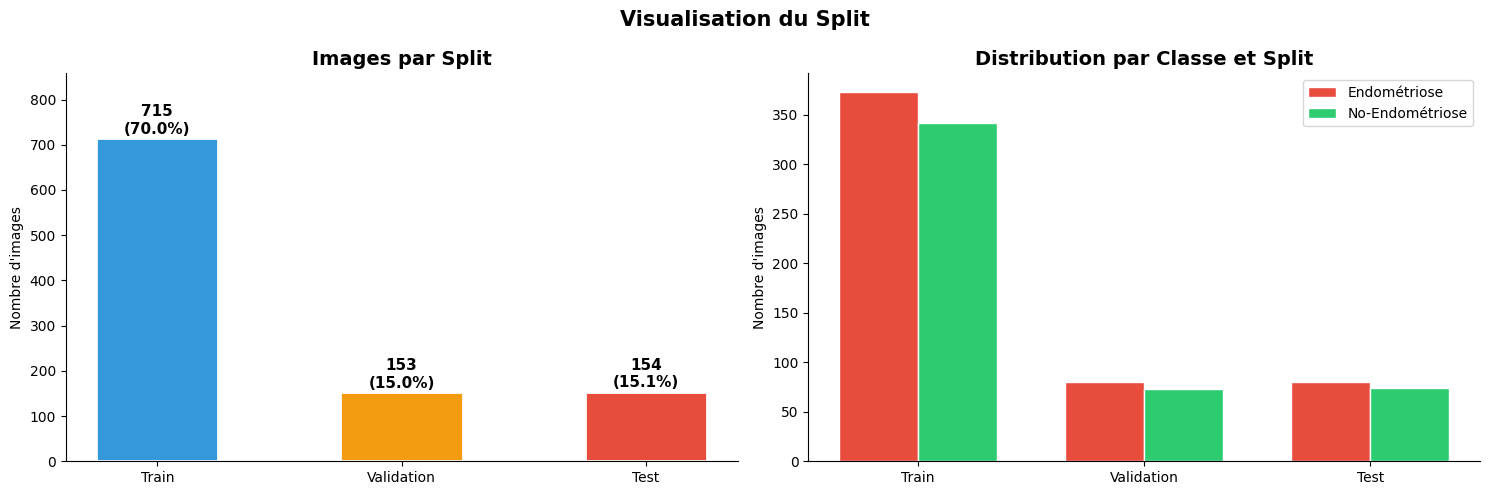

 Sauvegardé : split_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
splits = ['Train', 'Validation', 'Test']
sizes  = [len(df_train), len(df_val), len(df_test)]
colors_s = ['#3498DB', '#F39C12', '#E74C3C']

bars = axes[0].bar(splits, sizes, color=colors_s, edgecolor='white', linewidth=2, width=0.5)
for bar, s in zip(bars, sizes):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+3,
                 f'{s}\n({s/len(df)*100:.1f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Images par Split', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre d\'images')
axes[0].set_ylim(0, max(sizes)*1.2)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

x = np.arange(3); w = 0.35
e_counts  = [d['label'].value_counts().get('endometriosis',0)    for d in [df_train,df_val,df_test]]
ne_counts = [d['label'].value_counts().get('no_endometriosis',0) for d in [df_train,df_val,df_test]]
axes[1].bar(x-w/2, e_counts,  w, label='Endométriose',    color='#E74C3C', edgecolor='white')
axes[1].bar(x+w/2, ne_counts, w, label='No-Endométriose', color='#2ECC71', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(splits)
axes[1].set_title('Distribution par Classe et Split', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Nombre d\'images'); axes[1].legend()
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('Visualisation du Split', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : split_distribution.png')

🔧 Étape 3 — Démo Prétraitement

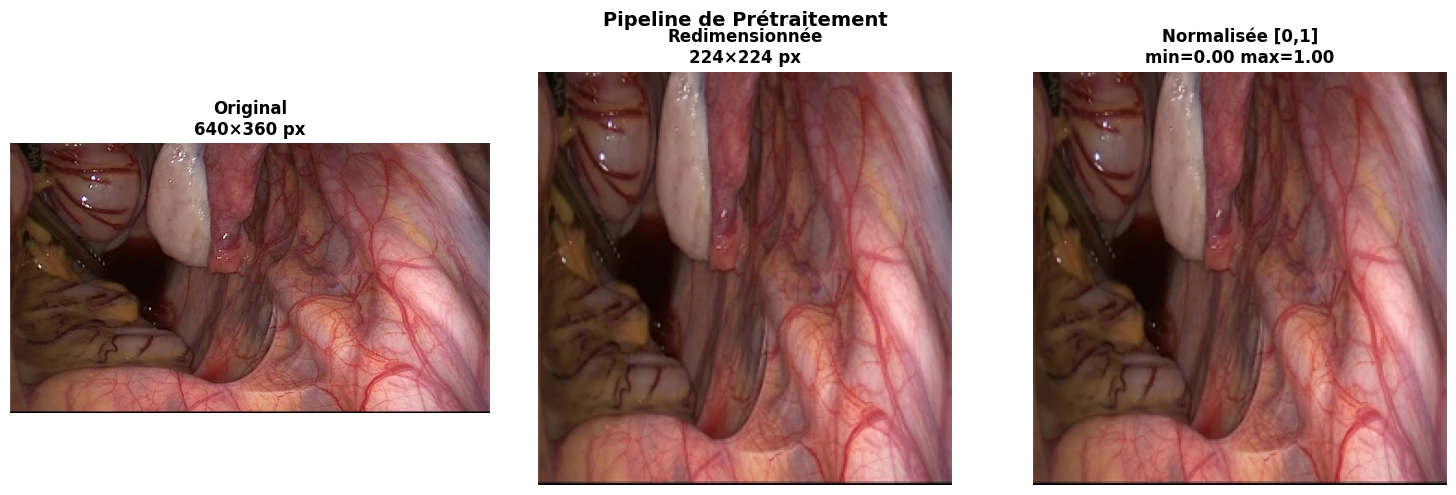

 Sauvegardé : preprocessing_demo.png


In [ ]:
sample_path = df_train.iloc[0]['path']
img_orig    = Image.open(sample_path).convert('RGB')
img_resized = img_orig.resize(IMG_SIZE)
img_norm    = np.array(img_resized) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_orig)
axes[0].set_title(f'Original\n{img_orig.size[0]}×{img_orig.size[1]} px', fontweight='bold')
axes[0].axis('off')
axes[1].imshow(img_resized)
axes[1].set_title('Redimensionnée\n224×224 px', fontweight='bold')
axes[1].axis('off')
axes[2].imshow(img_norm)
axes[2].set_title(f'Normalisée [0,1]\nmin={img_norm.min():.2f} max={img_norm.max():.2f}', fontweight='bold')
axes[2].axis('off')

plt.suptitle('Pipeline de Prétraitement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/preprocessing_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : preprocessing_demo.png')

In [ ]:
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(
    df, test_size=(1-TRAIN_RATIO), stratify=df['label'], random_state=42)
val_size = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
df_val, df_test = train_test_split(
    df_temp, test_size=(1-val_size), stratify=df_temp['label'], random_state=42)

print(f'✅ Train : {len(df_train)} | Val : {len(df_val)} | Test : {len(df_test)}')

✅ Train : 715 | Val : 153 | Test : 154


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary',
    shuffle=True, seed=42
)
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

print(' Générateurs :')
print(f'   Train : {train_generator.n} | Val : {val_generator.n} | Test : {test_generator.n}')
print(f'   Classes : {train_generator.class_indices}')
print('\n Augmentations train : Rotation | Shift | Zoom | Flip | Luminosité')

Found 715 images belonging to 2 classes.
Found 153 images belonging to 2 classes.
Found 154 images belonging to 2 classes.
 Générateurs :
   Train : 715 | Val : 153 | Test : 154
   Classes : {'endometriosis': 0, 'no_endometriosis': 1}

 Augmentations train : Rotation | Shift | Zoom | Flip | Luminosité


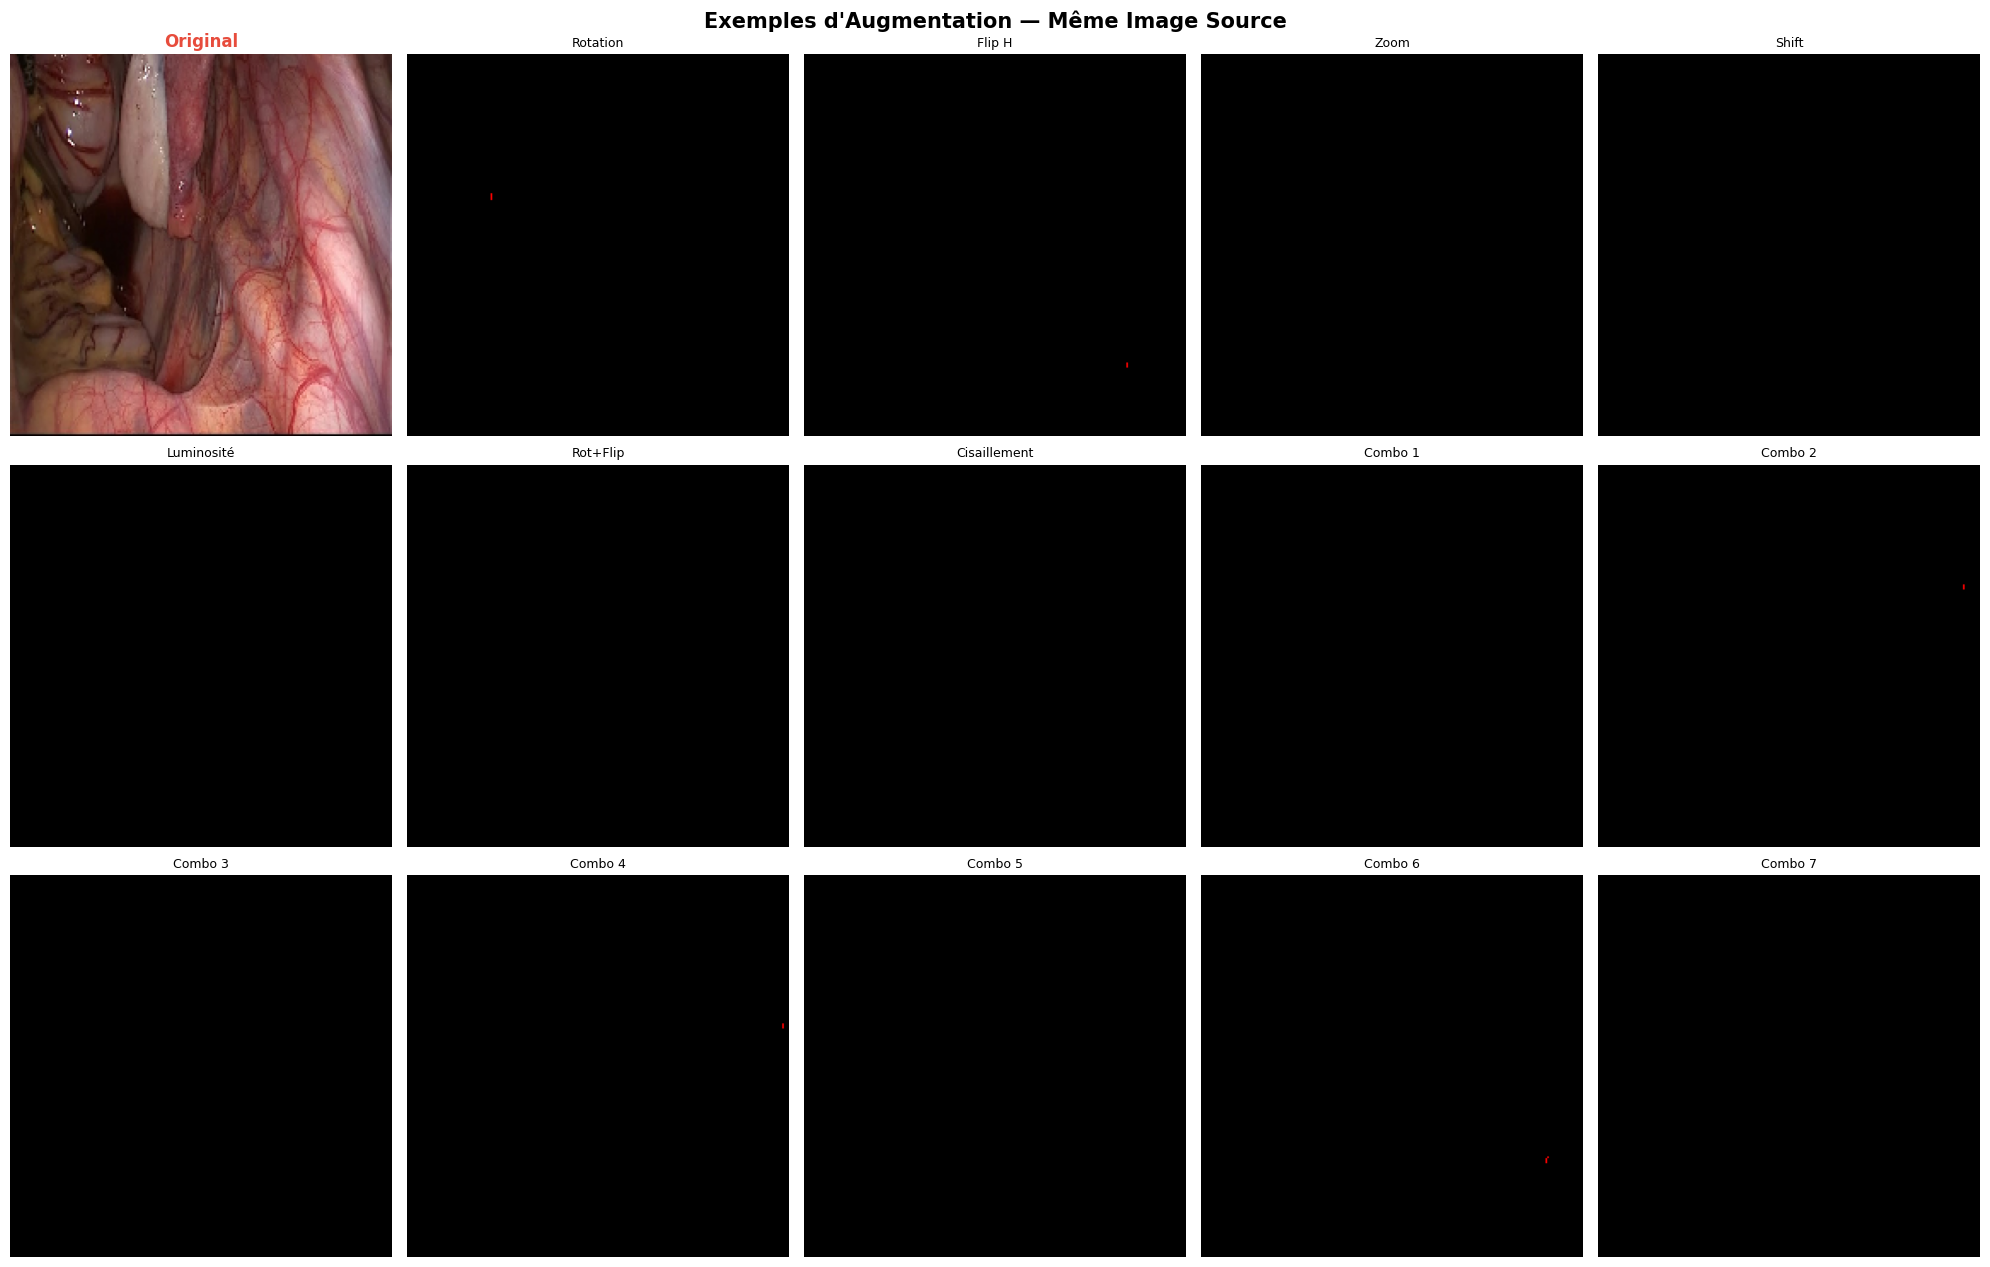

 Sauvegardé : augmentation_demo.png


In [ ]:
# Visualiser l'augmentation
aug_demo = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.15, horizontal_flip=True, vertical_flip=True,
    brightness_range=[0.8,1.2], fill_mode='nearest'
)
img_demo = load_img(sample_path, target_size=IMG_SIZE)
x_demo   = img_to_array(img_demo)/255.0
x_demo   = x_demo.reshape((1,)+x_demo.shape)
aug_iter = aug_demo.flow(x_demo, batch_size=1, seed=42)

fig, axes = plt.subplots(3, 5, figsize=(20, 13))
axes = axes.flatten()
axes[0].imshow(img_demo)
axes[0].set_title('Original', fontweight='bold', color='#E74C3C'); axes[0].axis('off')
for sp in axes[0].spines.values():
    sp.set_visible(True); sp.set_color('#E74C3C'); sp.set_linewidth(3)

labels = ['Rotation','Flip H','Zoom','Shift','Luminosité',
          'Rot+Flip','Cisaillement','Combo 1','Combo 2',
          'Combo 3','Combo 4','Combo 5','Combo 6','Combo 7']
for i in range(1, 15):
    aug_img = np.clip(next(aug_iter)[0], 0, 1)
    axes[i].imshow(aug_img); axes[i].set_title(labels[i-1], fontsize=9); axes[i].axis('off')

plt.suptitle('Exemples d\'Augmentation — Même Image Source', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : augmentation_demo.png')

In [ ]:
cw_array = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(cw_array))
class_names       = list(train_generator.class_indices.keys())

print('  Poids des Classes :')
for idx, weight in class_weight_dict.items():
    print(f'   Classe {idx} ({class_names[idx]:25}) : {weight:.4f}')

  Poids des Classes :
   Classe 0 (endometriosis            ) : 0.9584
   Classe 1 (no_endometriosis         ) : 1.0453


In [ ]:
config = {
    'IMG_SIZE':      list(IMG_SIZE),
    'INPUT_SHAPE':   list(INPUT_SHAPE),
    'BATCH_SIZE':    BATCH_SIZE,
    'TRAIN_DIR':     TRAIN_DIR,
    'VAL_DIR':       VAL_DIR,
    'TEST_DIR':      TEST_DIR,
    'WORK_DIR':      WORK_DIR,
    'n_train':       train_generator.n,
    'n_val':         val_generator.n,
    'n_test':        test_generator.n,
    'class_indices': train_generator.class_indices,
    'class_weight':  {str(k): float(v) for k, v in class_weight_dict.items()}
}
with open(f'{WORK_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('=' * 55)
print('      PRÉTRAITEMENT TERMINÉ')
print('=' * 55)
print(f'  data_split/')
print(f'  ├── train/  {train_generator.n} images')
print(f'  ├── val/    {val_generator.n} images')
print(f'  └── test/   {test_generator.n} images')
print()
print('   /content/config.json')
print('   /content/split_distribution.png')
print('   /content/preprocessing_demo.png')
print('   /content/augmentation_demo.png')
print()
print('=' * 55)

      PRÉTRAITEMENT TERMINÉ
  data_split/
  ├── train/  715 images
  ├── val/    153 images
  └── test/   154 images

   /content/config.json
   /content/split_distribution.png
   /content/preprocessing_demo.png
   /content/augmentation_demo.png



# 🔬 Projet Deep Learning — Détection de l'Endométriose
## Notebook 03 — CNN Baseline (From Scratch)

**Auteur :** [Ton Nom]  
**Encadrant :** M. Abdallah Khemais  
**Plateforme :** Google Colab  

---
### 🎯 Objectif
Construire un CNN **from scratch** qui servira de **référence baseline**.

### 🏗️ Architecture
```
Input (224×224×3)
  → BLOC 1 : Conv2D(32) → BatchNorm → ReLU → MaxPool → Dropout(0.25)
  → BLOC 2 : Conv2D(64) → BatchNorm → ReLU → MaxPool → Dropout(0.25)
  → BLOC 3 : Conv2D(128) → BatchNorm → ReLU → MaxPool → Dropout(0.25)
  → GlobalAveragePooling2D
  → Dense(256) → BatchNorm → ReLU → Dropout(0.5)
  → Dense(1, sigmoid)
```

> ⚠️ **Prérequis :** Les Notebooks 01 et 02 doivent avoir été exécutés dans la même session Colab

Étape 1 — Imports & Configuration


In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 7)
sns.set_style('whitegrid')

print('✅ Imports OK')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU dispo  : {tf.config.list_physical_devices("GPU")}')

✅ Imports OK
TensorFlow : 2.20.0
GPU dispo  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ===========================
#  CONFIGURATION COLAB
# ===========================
WORK_DIR    = '/content'
OUTPUT_DIR  = '/content/data_split'
TRAIN_DIR   = os.path.join(OUTPUT_DIR, 'train')
VAL_DIR     = os.path.join(OUTPUT_DIR, 'val')
TEST_DIR    = os.path.join(OUTPUT_DIR, 'test')
MODELS_DIR  = '/content/models'

IMG_SIZE    = (224, 224)
INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE  = 32
EPOCHS      = 50

os.makedirs(MODELS_DIR, exist_ok=True)

print('  Configuration :')
print(f'   TRAIN_DIR → existe : {os.path.exists(TRAIN_DIR)}')
print(f'   VAL_DIR   → existe : {os.path.exists(VAL_DIR)}')
print(f'   TEST_DIR  → existe : {os.path.exists(TEST_DIR)}')
print(f'   EPOCHS    : {EPOCHS}')
print(f'   BATCH     : {BATCH_SIZE}')

  Configuration :
   TRAIN_DIR → existe : True
   VAL_DIR   → existe : True
   TEST_DIR  → existe : True
   EPOCHS    : 50
   BATCH     : 32


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary',
    shuffle=True, seed=42
)
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

cw_array          = compute_class_weight('balanced',
                        classes=np.unique(train_generator.classes),
                        y=train_generator.classes)
class_weight_dict = dict(enumerate(cw_array))
CLASS_NAMES       = list(train_generator.class_indices.keys())

print('✅ Générateurs prêts')
print(f'   Train : {train_generator.n} | Val : {val_generator.n} | Test : {test_generator.n}')
print(f'   Classes : {train_generator.class_indices}')
print(f'   Weights : {class_weight_dict}')

Found 715 images belonging to 2 classes.
Found 153 images belonging to 2 classes.
Found 154 images belonging to 2 classes.
✅ Générateurs prêts
   Train : 715 | Val : 153 | Test : 154
   Classes : {'endometriosis': 0, 'no_endometriosis': 1}
   Weights : {0: np.float64(0.9584450402144772), 1: np.float64(1.0453216374269005)}


##  Étape 3 — Architecture CNN Baseline

In [ ]:
def build_cnn_baseline(input_shape=INPUT_SHAPE):
    """
    CNN Baseline from scratch.
    3 blocs Conv → GlobalAvgPool → Dense → Sigmoid
    Anti-overfitting : BatchNorm + Dropout + GlobalAvgPool
    """
    model = models.Sequential(name='CNN_Baseline')

    # BLOC 1
    model.add(layers.Conv2D(32, (3,3), padding='same',
                            input_shape=input_shape, kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # BLOC 2
    model.add(layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # BLOC 3
    model.add(layers.Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # CLASSIFICATION HEAD
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

cnn_model = build_cnn_baseline()
cnn_model.summary()

Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             

 Total params: 323,105 (1.23 MB)

 Trainable params: 321,697 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)
print(' Compilé — Adam lr=1e-4 | Binary Crossentropy')
print(f'   Paramètres totaux : {cnn_model.count_params():,}')

✅ Compilé — Adam lr=1e-4 | Binary Crossentropy
   Paramètres totaux : 323,105


##  Étape 5 — Callbacks

In [ ]:
MODEL_PATH = f'{MODELS_DIR}/cnn_baseline_best.keras'

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH, monitor='val_auc',
        mode='max', save_best_only=True, verbose=1
    )
]
print(' Callbacks : EarlyStopping | ReduceLR | ModelCheckpoint')

 Callbacks : EarlyStopping | ReduceLR | ModelCheckpoint


In [ ]:
print(' Entraînement CNN Baseline...')
print('=' * 55)

history_cnn = cnn_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f'\n Terminé — Époques : {len(history_cnn.history["loss"])}')

 Entraînement CNN Baseline...
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - accuracy: 0.5660 - auc: 0.5767 - loss: 0.7637 - precision: 0.5557 - recall: 0.5072
Epoch 1: val_auc improved from None to 0.49024, saving model to /content/models/cnn_baseline_best.keras

Epoch 1: finished saving model to /content/models/cnn_baseline_best.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.5986 - auc: 0.6206 - loss: 0.7216 - precision: 0.5841 - recall: 0.5585 - val_accuracy: 0.4771 - val_auc: 0.4902 - val_loss: 0.7054 - val_precision: 0.4771 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.6104 - auc: 0.6771 - loss: 0.6782 - precision: 0.5784 - recall: 0.5485
Epoch 2: val_auc improved from 0.49024 to 0.66122, saving model to /content/models/cnn_baseline_best.keras

Epoch 2: finished saving model to /content/models/cnn_baseline_best.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 559ms/step - accuracy: 0.6378 - auc: 0.6918 - l

 Étape 7 — Courbes d'Apprentissage

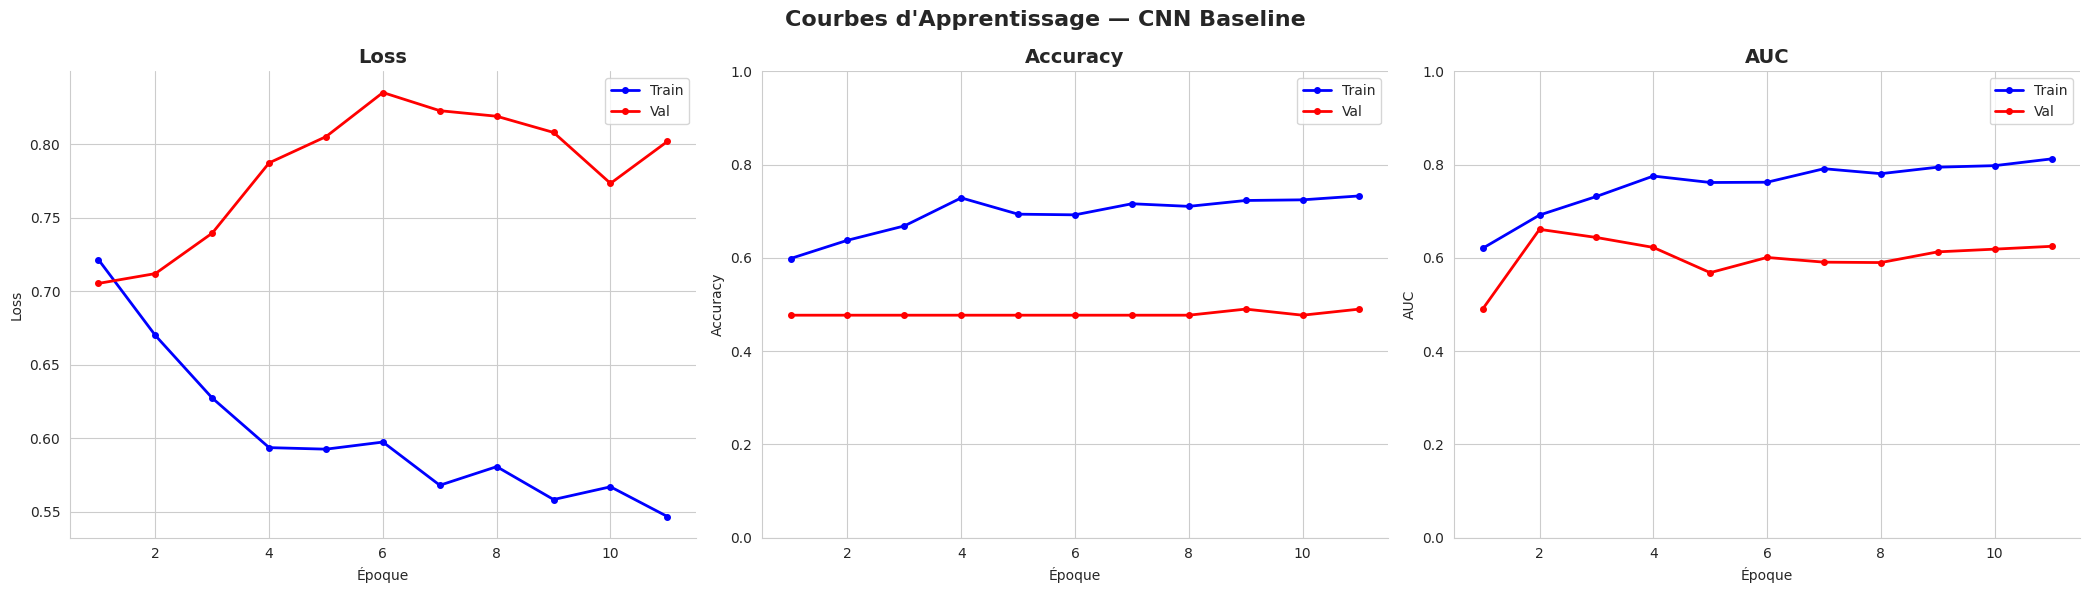


 Diagnostic :
   Train Acc : 0.7329 | Val Acc : 0.4902 | Gap : 0.2427
     OVERFITTING → plus de Dropout ou données


In [ ]:
hist = history_cnn.history
ep   = range(1, len(hist['loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (tk, vk, title) in zip(axes, [
    ('loss',     'val_loss',     'Loss'),
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('auc',      'val_auc',      'AUC')
]):
    ax.plot(ep, hist[tk], 'b-o', label='Train', lw=2, ms=4)
    ax.plot(ep, hist[vk], 'r-o', label='Val',   lw=2, ms=4)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Époque'); ax.set_ylabel(title); ax.legend()
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if title in ['Accuracy','AUC']: ax.set_ylim(0, 1)

plt.suptitle('Courbes d\'Apprentissage — CNN Baseline', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/curves_CNN_Baseline.png', dpi=150, bbox_inches='tight')
plt.show()

train_acc = hist['accuracy'][-1]
val_acc   = hist['val_accuracy'][-1]
gap       = train_acc - val_acc
print(f'\n Diagnostic :')
print(f'   Train Acc : {train_acc:.4f} | Val Acc : {val_acc:.4f} | Gap : {gap:.4f}')
if gap > 0.10:       print('     OVERFITTING → plus de Dropout ou données')
elif val_acc < 0.65: print('     UNDERFITTING → modèle trop simple')
else:                print('    Apprentissage équilibré')

In [ ]:
best_cnn = keras.models.load_model(MODEL_PATH)
test_generator.reset()
y_pred_proba = best_cnn.predict(test_generator, verbose=1).flatten()
y_pred       = (y_pred_proba > 0.5).astype(int)
y_true       = test_generator.classes

print('\n📋 Rapport de Classification :')
print('=' * 55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step

📋 Rapport de Classification :
                  precision    recall  f1-score   support

   endometriosis       0.00      0.00      0.00        80
no_endometriosis       0.48      1.00      0.65        74

        accuracy                           0.48       154
       macro avg       0.24      0.50      0.32       154
    weighted avg       0.23      0.48      0.31       154



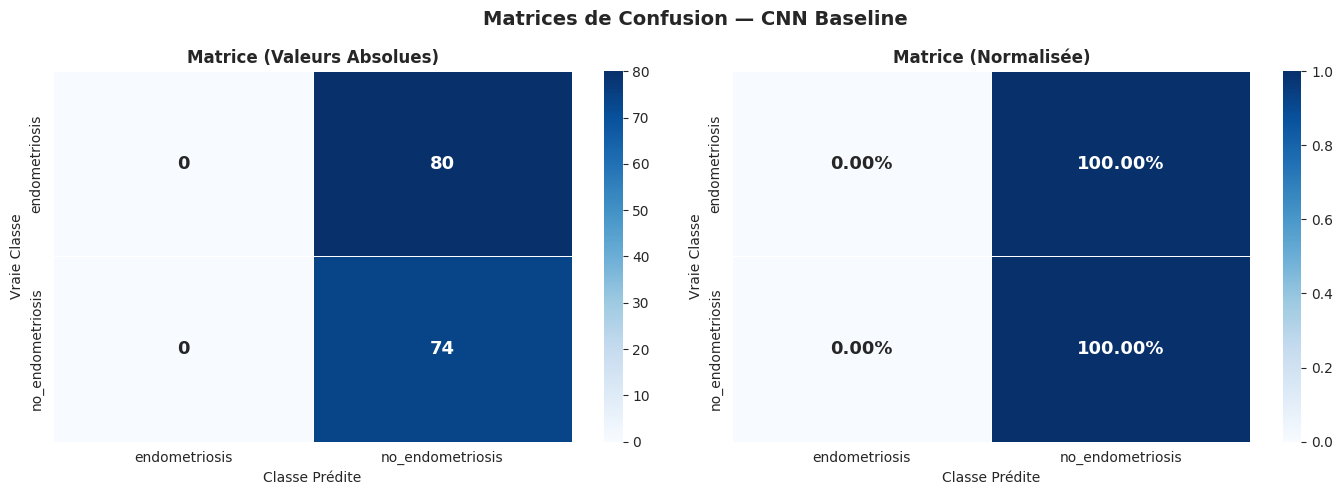


🔍 Interprétation :
   TP=74 ✅ | TN=0 ✅ | FP=80 ⚠️ | FN=0 ❌
   Sensibilité : 1.0000 | Spécificité : 0.0000


In [ ]:
# Matrice de confusion
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], ['d', '.2%'], ['Valeurs Absolues', 'Normalisée']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, linecolor='white',
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(f'Matrice ({title})', fontweight='bold')
    ax.set_ylabel('Vraie Classe'); ax.set_xlabel('Classe Prédite')

plt.suptitle('Matrices de Confusion — CNN Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/cm_CNN_Baseline.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\n🔍 Interprétation :')
print(f'   TP={tp} ✅ | TN={tn} ✅ | FP={fp} ⚠️ | FN={fn} ❌')
print(f'   Sensibilité : {tp/(tp+fn):.4f} | Spécificité : {tn/(tn+fp):.4f}')

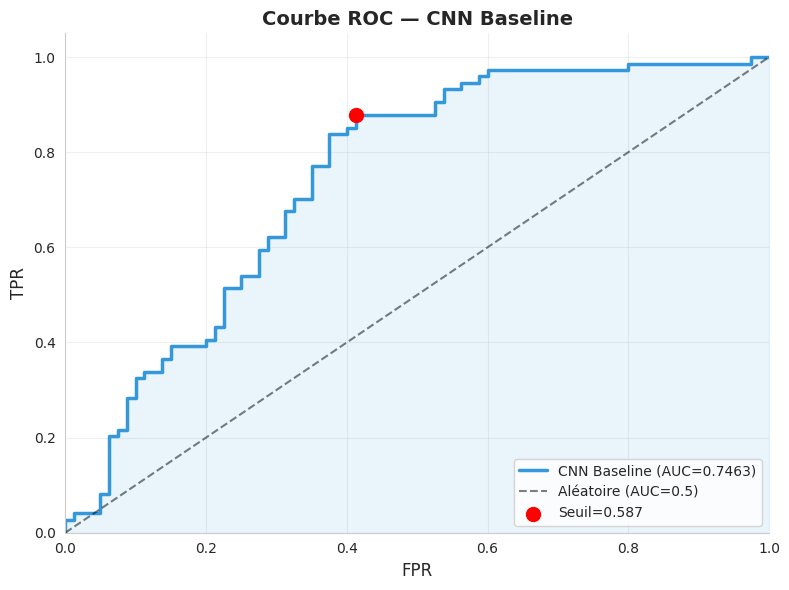


📊 AUC = 0.7463  → 🟡 Acceptable


In [ ]:
# Courbe ROC
fpr, tpr, thresh = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)
opt_idx = np.argmax(tpr - fpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#3498DB', lw=2.5, label=f'CNN Baseline (AUC={roc_auc:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Aléatoire (AUC=0.5)')
ax.scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=100, zorder=5,
           label=f'Seuil={thresh[opt_idx]:.3f}')
ax.fill_between(fpr, tpr, alpha=0.1, color='#3498DB')
ax.set_xlim(0,1); ax.set_ylim(0,1.05)
ax.set_xlabel('FPR', fontsize=12); ax.set_ylabel('TPR', fontsize=12)
ax.set_title('Courbe ROC — CNN Baseline', fontsize=14, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/roc_CNN_Baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 AUC = {roc_auc:.4f}  ', end='')
if roc_auc >= 0.9:   print('→ 🏆 Excellent')
elif roc_auc >= 0.8: print('→ ✅ Très bon')
elif roc_auc >= 0.7: print('→ 🟡 Acceptable')
else:                print('→ ❌ Transfer Learning nécessaire')

In [ ]:
results_cnn = {
    'model':          'CNN Baseline',
    'accuracy':       float(accuracy_score(y_true, y_pred)),
    'precision':      float(precision_score(y_true, y_pred, average='weighted')),
    'recall':         float(recall_score(y_true, y_pred, average='weighted')),
    'f1_score':       float(f1_score(y_true, y_pred, average='weighted')),
    'auc':            float(roc_auc),
    'epochs_trained': len(history_cnn.history['loss'])
}
with open(f'{WORK_DIR}/results_cnn_baseline.json', 'w') as f:
    json.dump(results_cnn, f, indent=2)

print('=' * 55)
print('     📊 RÉSULTATS FINAUX — CNN BASELINE')
print('=' * 55)
for k, v in results_cnn.items():
    print(f'   {k:20} : {v:.4f}' if isinstance(v, float) else f'   {k:20} : {v}')
print()
print('  ✅ /content/models/cnn_baseline_best.keras')
print('  ✅ /content/results_cnn_baseline.json')
print('  ✅ /content/curves_CNN_Baseline.png')
print('  ✅ /content/cm_CNN_Baseline.png')
print('  ✅ /content/roc_CNN_Baseline.png')
print()
print('  🔜 Prochaine étape : Notebook 04 — Transfer Learning')
print('=' * 55)

     📊 RÉSULTATS FINAUX — CNN BASELINE
   model                : CNN Baseline
   accuracy             : 0.4805
   precision            : 0.2309
   recall               : 0.4805
   f1_score             : 0.3119
   auc                  : 0.7463
   epochs_trained       : 11

  ✅ /content/models/cnn_baseline_best.keras
  ✅ /content/results_cnn_baseline.json
  ✅ /content/curves_CNN_Baseline.png
  ✅ /content/cm_CNN_Baseline.png
  ✅ /content/roc_CNN_Baseline.png

  🔜 Prochaine étape : Notebook 04 — Transfer Learning


# 🔬 Projet Deep Learning — Détection de l'Endométriose
## Notebook 04 — Transfer Learning (VGG16 + ResNet50)

**Auteur :** [Ton Nom]  
**Encadrant :** M. Abdallah Khemais  
**Plateforme :** Google Colab  

---
### 🎯 Objectif
Utiliser des modèles pré-entraînés sur ImageNet pour améliorer les performances par rapport au CNN Baseline.

### 💡 Principe du Transfer Learning
```
ImageNet (1M images) → Poids pré-entraînés
         ↓
Geler les couches convolutives (features déjà apprises)
         ↓
Ajouter un classifier custom pour notre problème
         ↓
Fine-tuning : dégeler quelques couches pour adapter
```

### 🏗️ Modèles utilisés
- **VGG16** — Architecture simple et efficace
- **ResNet50** — Architecture avec connexions résiduelles

In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 7)
sns.set_style('whitegrid')

print('✅ Imports OK')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU dispo  : {tf.config.list_physical_devices("GPU")}')

✅ Imports OK
TensorFlow : 2.20.0
GPU dispo  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ===========================
#  CONFIGURATION COLAB
# ===========================
WORK_DIR    = '/content'
OUTPUT_DIR  = '/content/data_split'
TRAIN_DIR   = os.path.join(OUTPUT_DIR, 'train')
VAL_DIR     = os.path.join(OUTPUT_DIR, 'val')
TEST_DIR    = os.path.join(OUTPUT_DIR, 'test')
MODELS_DIR  = '/content/models'

IMG_SIZE    = (224, 224)
INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE  = 32
EPOCHS      = 50

os.makedirs(MODELS_DIR, exist_ok=True)

print('⚙️  Configuration :')
print(f'   TRAIN_DIR → existe : {os.path.exists(TRAIN_DIR)}')
print(f'   VAL_DIR   → existe : {os.path.exists(VAL_DIR)}')
print(f'   TEST_DIR  → existe : {os.path.exists(TEST_DIR)}')

⚙️  Configuration :
   TRAIN_DIR → existe : True
   VAL_DIR   → existe : True
   TEST_DIR  → existe : True


## 🔄 Étape 2 — Recréation des Générateurs

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary',
    shuffle=True, seed=42
)
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

cw_array          = compute_class_weight('balanced',
                        classes=np.unique(train_generator.classes),
                        y=train_generator.classes)
class_weight_dict = dict(enumerate(cw_array))
CLASS_NAMES       = list(train_generator.class_indices.keys())

print('✅ Générateurs prêts')
print(f'   Train : {train_generator.n} | Val : {val_generator.n} | Test : {test_generator.n}')
print(f'   Classes : {train_generator.class_indices}')

Found 715 images belonging to 2 classes.
Found 153 images belonging to 2 classes.
Found 154 images belonging to 2 classes.
✅ Générateurs prêts
   Train : 715 | Val : 153 | Test : 154
   Classes : {'endometriosis': 0, 'no_endometriosis': 1}


---
# 🔵 PARTIE 1 — VGG16

## Architecture VGG16
```
Input (224×224×3)
  → VGG16 Base (poids ImageNet, couches gelées)
  → GlobalAveragePooling2D
  → Dense(256) → BatchNorm → ReLU → Dropout(0.5)
  → Dense(1, sigmoid)
```

## 🏗️ Étape 3 — Construction VGG16

In [ ]:
def build_vgg16(input_shape=INPUT_SHAPE, fine_tune_at=None):
    """
    VGG16 avec Transfer Learning.
    fine_tune_at : numéro de couche à partir duquel dégeler (None = tout gelé)
    """
    # Charger VGG16 pré-entraîné sur ImageNet SANS la tête de classification
    base_model = VGG16(
        weights='imagenet',      # Poids pré-entraînés
        include_top=False,       # Pas de la couche Dense finale
        input_shape=input_shape
    )

    # Geler TOUTES les couches de la base
    base_model.trainable = False

    # Fine-tuning : dégeler à partir d'une certaine couche
    if fine_tune_at is not None:
        for layer in base_model.layers[fine_tune_at:]:
            layer.trainable = True

    # Construire le modèle complet
    inputs  = keras.Input(shape=input_shape)
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256)(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Activation('relu')(x)
    x       = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name='VGG16_Transfer')
    return model, base_model

vgg16_model, vgg16_base = build_vgg16()

print('✅ VGG16 construit')
print(f'   Couches totales     : {len(vgg16_base.layers)}')
print(f'   Couches entraînable : {sum(1 for l in vgg16_model.layers if l.trainable)}')
print(f'   Paramètres totaux   : {vgg16_model.count_params():,}')
print(f'   Paramètres gelés    : {sum(np.prod(v.shape) for v in vgg16_base.non_trainable_weights):,}')
vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ VGG16 construit
   Couches totales     : 19
   Couches entraînable : 7
   Paramètres totaux   : 14,847,297
   Paramètres gelés    : 14,714,688


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 132,097 (516.00 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

## ⚙️ Étape 4 — Compilation VGG16 (Phase 1)

In [ ]:
# Phase 1 : LR élevé car base gelée
vgg16_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print('✅ VGG16 compilé — Phase 1 (base gelée)')
print('   Optimizer : Adam lr=1e-3')
print('   Loss      : Binary Crossentropy')

✅ VGG16 compilé — Phase 1 (base gelée)
   Optimizer : Adam lr=1e-3
   Loss      : Binary Crossentropy


## 🚀 Étape 5 — Entraînement VGG16 Phase 1

In [ ]:
VGG16_PATH = f'{MODELS_DIR}/vgg16_best.keras'

callbacks_vgg16 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint(filepath=VGG16_PATH, monitor='val_auc',
                    mode='max', save_best_only=True, verbose=1)
]

print('🚀 Entraînement VGG16 — Phase 1 (base gelée)...')
print('=' * 55)

history_vgg16_p1 = vgg16_model.fit(
    train_generator,
    epochs=20,                        # Phase 1 : moins d'époques
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_vgg16,
    verbose=1
)

print(f'\n✅ Phase 1 terminée — Époques : {len(history_vgg16_p1.history["loss"])}')

🚀 Entraînement VGG16 — Phase 1 (base gelée)...
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5839 - auc: 0.6443 - loss: 0.7055 - precision: 0.5614 - recall: 0.5388
Epoch 1: val_auc improved from None to 0.87354, saving model to /content/models/vgg16_best.keras

Epoch 1: finished saving model to /content/models/vgg16_best.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.6266 - auc: 0.6816 - loss: 0.6986 - precision: 0.6081 - recall: 0.6170 - val_accuracy: 0.4902 - val_auc: 0.8735 - val_loss: 0.6736 - val_precision: 0.4834 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.7348 - auc: 0.7967 - loss: 0.5572 - precision: 0.7052 - recall: 0.7067
Epoch 2: val_auc did not improve from 0.87354
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 639ms/step - accuracy: 0.7399 - auc: 0.8136 - loss: 0.5299 - precision: 0.7308 - recall: 0.7222 - val_accuracy: 0.7386 - val_auc: 0.8728 - val_loss: 0.6364 - val_precision: 0.6486 - val_r

##  Étape 6 — Fine-Tuning VGG16 (Phase 2)

> **Fine-tuning** : On dégèle les dernières couches de VGG16 pour les adapter à nos images médicales

In [ ]:
# Dégeler les 4 dernières couches de VGG16
vgg16_base.trainable = True
fine_tune_at = -4  # Dégeler les 4 dernières couches

for layer in vgg16_base.layers[:fine_tune_at]:
    layer.trainable = False
for layer in vgg16_base.layers[fine_tune_at:]:
    layer.trainable = True

# Recompiler avec LR très faible pour le fine-tuning
vgg16_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # LR très faible !
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

print('🔓 Fine-tuning VGG16 activé')
print(f'   Couches dégelées    : {sum(1 for l in vgg16_base.layers if l.trainable)}')
print(f'   Optimizer           : Adam lr=1e-5 (très faible pour fine-tuning)')

print('\n Entraînement VGG16 — Phase 2 (fine-tuning)...')
print('=' * 55)

callbacks_vgg16_ft = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint(filepath=VGG16_PATH, monitor='val_auc',
                    mode='max', save_best_only=True, verbose=1)
]

history_vgg16_p2 = vgg16_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_vgg16_ft,
    verbose=1
)

print(f'\nFine-tuning terminé — Époques : {len(history_vgg16_p2.history["loss"])}')

🔓 Fine-tuning VGG16 activé
   Couches dégelées    : 4
   Optimizer           : Adam lr=1e-5 (très faible pour fine-tuning)

 Entraînement VGG16 — Phase 2 (fine-tuning)...
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.8811 - auc: 0.9527 - loss: 0.2800 - precision: 0.8459 - recall: 0.9188
Epoch 1: val_auc improved from None to 0.96404, saving model to /content/models/vgg16_best.keras

Epoch 1: finished saving model to /content/models/vgg16_best.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 888ms/step - accuracy: 0.8839 - auc: 0.9518 - loss: 0.2835 - precision: 0.8548 - recall: 0.9123 - val_accuracy: 0.9020 - val_auc: 0.9640 - val_loss: 0.2848 - val_precision: 0.8537 - val_recall: 0.9589 - learning_rate: 1.0000e-05
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.8629 - auc: 0.9503 - loss: 0.2848 - precision: 0.8527 - recall: 0.8718
Epoch 2: val_auc improved from 0.96404 to 0.97303, saving model to /content/models/vgg16_best.keras

Epoch 2: finished saving mode